# Destilacion Espacial de Memoria (Spatial Feature Distillation)

**Problema del experimento anterior:** La destilacion 1D (post-pooling, 512 valores) no provee
suficiente señal de gradiente al VAE. El MSE entre vectores promediados en espacio oculta
las diferencias locales que tienen ruido, resultando en una ganancia insignificante (+1.15%).

**Solucion: Destilacion en el espacio 2D completo [B, 512, 7, 7]**

$$\mathcal{L}_{\text{Phase2}} = \text{CE}(\hat{y}, y) + \lambda_{\text{vae}}(\mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KLD}}) + \lambda_{\text{spatial}} \cdot \text{MSE}(\text{enhanced\_spatial\_noisy}, \text{spatial\_feats\_clean})$$

Destilar sobre los 25,088 elementos del mapa espacial (vs solo 512) obliga a la memoria a:
- Reconstruir la textura local de cada region del mapa de features
- No puede "promediar" el problema: cada canal y cada posicion (7x7) debe coincidir con el experto

## Por que esto deberia funcionar
El ruido gaussiano en la imagen de entrada se propaga al mapa backbone como pequenas perturbaciones
distribuidas en todos los canales y posiciones espaciales. El `conv_vae` tiene exactamente la
arquitectura para operar sobre esa topologia [B, 512, 7, 7] y corregir esas perturbaciones localmente.
El MSE espacial provee el gradiente preciso para cada posicion, guiando la correccion celda por celda.

## Protocolo de Comparacion Justa (3-way)
| Modelo | Fase 1 | Fase 2 | Que se entrena en Fase 2 |
|---|---|---|---|
| **ResNet Fase 1 (techo)** | `fc` en datos limpios | — | — |
| **ResNet + Spatial Distill** | `fc` en datos limpios | Backbone descongelado con `CE + MSE_spatial(noisy_feats, clean_feats)` | Backbone (excepto primeras capas) |
| **DeMemte + Spatial Distill** | Todo en datos limpios | `CE + VAE + MSE_spatial(enhanced, clean)` con clasificador **congelado** | `conv_vae`, `signal_gamma`, `memory_scale` |

In [1]:
import os
import copy
import random
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Componentes

### Cambios clave vs notebook anterior
- `DeMemte_Spatial.forward` retorna **8 valores** incluyendo `enhanced_spatial` [B, 512, 7, 7] y `spatial_feats` [B, 512, 7, 7]
- Nuevo metodo `get_clean_spatial(x)` retorna el mapa backbone sin gradientes [B, 512, 7, 7]
- La destilacion en Fase 2 opera sobre el espacio completo: `MSE(enhanced_spatial, clean_spatial)` en 25,088 elementos vs los 512 anteriores

In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, hard_threshold=0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))
        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x):
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft
        return F.linear(x, self.weight * gate, self.bias)

    def sparsity_loss(self):
        return torch.sigmoid(self.logits / self.temperature).mean()


class ConvVAE(nn.Module):
    def __init__(self, channels=512, latent_dim=128, spatial=7):
        super().__init__()
        self.channels = channels
        self.spatial = spatial
        self.enc = nn.Sequential(
            nn.Conv2d(channels, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),       nn.BatchNorm2d(128), nn.ReLU(),
        )
        flat_dim = 128 * spatial * spatial
        self.fc_mu     = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)
        self.fc_dec    = nn.Linear(latent_dim, flat_dim)
        self.dec = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, channels, 3, padding=1),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def decode(self, z):
        return self.dec(self.fc_dec(z).view(-1, 128, self.spatial, self.spatial))

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar


class DeMemte_Spatial(nn.Module):
    """
    Version con Destilacion Espacial.
    forward retorna 8 valores:
      (logits, x_rec_1d, mu, logvar, features_1d, enhanced_1d, enhanced_spatial, spatial_feats)
    Los ultimos dos son tensores [B, 512, 7, 7] para calcular el MSE espacial en Fase 2.
    """
    def __init__(self, backbone, conv_vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.conv_vae = conv_vae
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            spatial_feats = self.backbone(x)                        # [B, 512, 7, 7]  — congelado

        spatial_rec, mu, logvar = self.conv_vae(spatial_feats)      # [B, 512, 7, 7]
        recon_diff = ((spatial_feats - spatial_rec) ** 2).mean(dim=1, keepdim=True)
        signal = torch.exp(-recon_diff * F.softplus(self.signal_gamma))
        enhanced_spatial = spatial_feats + self.memory_scale * signal * spatial_rec  # [B, 512, 7, 7]

        features = self.feat_norm(self.pool(spatial_feats).flatten(1))
        enhanced = self.feat_norm(self.pool(enhanced_spatial).flatten(1))
        logits   = self.classifier(enhanced)
        x_rec_1d = self.pool(spatial_rec).flatten(1)

        return logits, x_rec_1d, mu, logvar, features, enhanced, enhanced_spatial, spatial_feats

    def get_clean_spatial(self, x):
        """Retorna el mapa backbone [B, 512, 7, 7] sin gradientes — senal teacher."""
        with torch.no_grad():
            return self.backbone(x)

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self


def make_spatial_backbone():
    base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base.children())[:-2])
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()
    return backbone


EMBEDDING_DIM = 512
NUM_CLASSES   = 102
LATENT_DIM    = 128
SPATIAL_DIM   = 7
print('Componentes definidos. DeMemte_Spatial retorna 8 valores (incluye enhanced_spatial y spatial_feats).')

Componentes definidos. DeMemte_Spatial retorna 8 valores (incluye enhanced_spatial y spatial_feats).


## Datos, hiperparametros y utilidades

In [3]:
BATCH_SIZE       = 64
NOISE_STD        = 0.5
EPOCHS_P1        = 15
EPOCHS_P2        = 15
SPATIAL_MSE_W    = 0.01 * 100   # Peso destilacion espacial (25088 elementos → escala distinta a 1D)
VAE_WEIGHT       = 0.1
SPARSITY_WEIGHT  = 0.002
DATA_DIR         = '../data'

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

trainset = torchvision.datasets.Flowers102(root=DATA_DIR, split='train', download=True, transform=transform_train)
testset  = torchvision.datasets.Flowers102(root=DATA_DIR, split='test',  download=True, transform=transform_test)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'Train: {len(trainset)} | Test: {len(testset)}')


def add_noise(x, std=NOISE_STD):
    return x + torch.randn_like(x) * std


@torch.no_grad()
def evaluate(model, loader, noise_std=0.0, is_dememte=True):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if noise_std > 0:
            x = add_noise(x, std=noise_std)
        logits = model(x)[0] if is_dememte else model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)
    return 100.0 * correct / total

print('Datos y utilidades listos.')
print(f'SPATIAL_MSE_W = {SPATIAL_MSE_W}  (destilacion sobre [B, 512, {SPATIAL_DIM}, {SPATIAL_DIM}] = 25,088 elementos)')

Train: 1020 | Test: 6149
Datos y utilidades listos.
SPATIAL_MSE_W = 1.0  (destilacion sobre [B, 512, 7, 7] = 25,088 elementos)


---
## 1. ResNet Baseline — 2 Fases con Destilacion Espacial

### Fase 1: Experto Clean
Backbone congelado + `fc` entrenado 15 ep sobre datos limpios. Establece el techo.

### Fase 2: Destilacion Espacial en el Backbone
Aqui hacemos algo diferente al notebook anterior: descongelamos las **ultimas capas del backbone**
(`layer3` y `layer4` de ResNet18) y entrenamos con ruido + MSE contra el backbone teacher congelado
al nivel de los mapas espaciales [B, 512, 7, 7].

**Hipotesis:** Sin un modulo de memoria dedicado, ResNet debe destruir su extractor de features
limpio para adaptarlo al ruido, degradando el Clean Acc. Esto contrasta con DeMemte, donde el
backbone permanece intacto y solo el VAE absorbe la adaptacion.

In [4]:
#  ResNet: Fase 1 (Clean Expert) ─

def get_resnet_full(num_classes=NUM_CLASSES):
    """ResNet18 completo con backbone entrenable (para Fase 2 spatial)."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


resnet = get_resnet_full()
opt_resnet_p1 = optim.Adam(resnet.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_resnet_p1 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

print('=== ResNet Fase 1: Experto Clean (fc unicamente) ===')
for epoch in range(EPOCHS_P1):
    resnet.train()
    correct, total = 0, 0
    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        opt_resnet_p1.zero_grad()
        loss = criterion(resnet(x), y)
        loss.backward()
        opt_resnet_p1.step()
        with torch.no_grad():
            correct += (resnet(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    train_acc = 100.0 * correct / total
    clean_acc = evaluate(resnet, testloader, noise_std=0.0,      is_dememte=False)
    noisy_acc = evaluate(resnet, testloader, noise_std=NOISE_STD, is_dememte=False)
    history_resnet_p1['train_acc'].append(train_acc)
    history_resnet_p1['clean_acc'].append(clean_acc)
    history_resnet_p1['noisy_acc'].append(noisy_acc)
    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

resnet_p1_clean = history_resnet_p1['clean_acc'][-1]
resnet_p1_noisy = history_resnet_p1['noisy_acc'][-1]
print(f'\n>>> ResNet Fase 1 -> Clean: {resnet_p1_clean:.2f}% | Noisy: {resnet_p1_noisy:.2f}%')
print(f'>>> TECHO ResNet: {resnet_p1_clean:.2f}%')

=== ResNet Fase 1: Experto Clean (fc unicamente) ===
  Epoch 1/15 | Train: 6.1% | Clean: 14.3% | Noisy: 4.7%
  Epoch 2/15 | Train: 36.8% | Clean: 44.0% | Noisy: 13.1%
  Epoch 3/15 | Train: 66.5% | Clean: 57.5% | Noisy: 17.2%
  Epoch 4/15 | Train: 84.9% | Clean: 67.8% | Noisy: 22.5%
  Epoch 5/15 | Train: 88.8% | Clean: 70.5% | Noisy: 25.0%
  Epoch 6/15 | Train: 93.4% | Clean: 74.6% | Noisy: 30.1%
  Epoch 7/15 | Train: 95.1% | Clean: 76.1% | Noisy: 28.8%
  Epoch 8/15 | Train: 96.6% | Clean: 76.4% | Noisy: 32.3%
  Epoch 9/15 | Train: 97.0% | Clean: 78.2% | Noisy: 30.0%
  Epoch 10/15 | Train: 97.5% | Clean: 79.1% | Noisy: 31.3%
  Epoch 11/15 | Train: 98.4% | Clean: 79.6% | Noisy: 33.8%
  Epoch 12/15 | Train: 98.9% | Clean: 79.6% | Noisy: 33.0%
  Epoch 13/15 | Train: 98.8% | Clean: 79.8% | Noisy: 32.8%
  Epoch 14/15 | Train: 99.5% | Clean: 80.2% | Noisy: 34.5%
  Epoch 15/15 | Train: 99.6% | Clean: 80.1% | Noisy: 33.7%

>>> ResNet Fase 1 -> Clean: 80.14% | Noisy: 33.71%
>>> TECHO ResNet: 80.

In [5]:
#  ResNet: Fase 2 (Spatial Backbone Distillation) ─
#
# Descongelamos layer3 y layer4 del backbone (ultimas capas convolucionales).
# Teacher = clon congelado del ResNet experto limpio.
# Loss = CE(logits_noisy, y) + SPATIAL_MSE_W * MSE(feats_noisy_7x7, feats_clean_7x7)
# El backbone tiene que aprender a filtrar el ruido en su propio espacio de features.

# Clon teacher congelado
resnet_teacher = copy.deepcopy(resnet)
for p in resnet_teacher.parameters():
    p.requires_grad = False
resnet_teacher.eval()

# Extraer submódulos del backbone para destilacion espacial
# resnet = [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc]
# Indices:    0      1    2      3        4       5       6       7      8      fc
resnet_backbone_teacher = nn.Sequential(*list(resnet_teacher.children())[:-2]).eval()

# Descongelar layer3 (idx 6) y layer4 (idx 7) del backbone actual
resnet_backbone_student = nn.Sequential(*list(resnet.children())[:-2])
for i, child in enumerate(resnet_backbone_student.children()):
    if i >= 6:   # layer3 y layer4
        for p in child.parameters():
            p.requires_grad = True

trainable_rn = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'ResNet Fase 2: {trainable_rn:,} parametros entrenables (layer3 + layer4 + fc)')

opt_resnet_p2 = optim.Adam(
    [p for p in resnet.parameters() if p.requires_grad],
    lr=1e-4
)

history_resnet_p2 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': [], 'spatial_mse': []}

print('\n=== ResNet Fase 2: Destilacion Espacial del Backbone ===')
print(f'    Loss = CE + {SPATIAL_MSE_W} * MSE(feats_noisy[B,512,7,7], feats_clean_teacher[B,512,7,7])')
print()
for epoch in range(EPOCHS_P2):
    resnet.train()
    resnet_backbone_teacher.eval()
    correct, total = 0, 0
    epoch_smse = 0.0
    n_batches  = 0

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        x_noisy = add_noise(x)

        with torch.no_grad():
            spatial_clean = resnet_backbone_teacher(x)           # [B, 512, 7, 7] sin grad

        opt_resnet_p2.zero_grad()
        logits_noisy  = resnet(x_noisy)
        spatial_noisy = resnet_backbone_student(x_noisy)         # [B, 512, 7, 7] con grad

        ce_loss    = criterion(logits_noisy, y)
        smse_loss  = F.mse_loss(spatial_noisy, spatial_clean)
        loss       = ce_loss + SPATIAL_MSE_W * smse_loss

        loss.backward()
        opt_resnet_p2.step()

        correct      += (logits_noisy.argmax(1) == y).sum().item()
        total        += y.size(0)
        epoch_smse   += smse_loss.item()
        n_batches    += 1

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(resnet, testloader, noise_std=0.0,       is_dememte=False)
    noisy_acc = evaluate(resnet, testloader, noise_std=NOISE_STD, is_dememte=False)
    avg_smse  = epoch_smse / n_batches
    history_resnet_p2['train_acc'].append(train_acc)
    history_resnet_p2['clean_acc'].append(clean_acc)
    history_resnet_p2['noisy_acc'].append(noisy_acc)
    history_resnet_p2['spatial_mse'].append(avg_smse)
    print(f'  Epoch {epoch+1}/{EPOCHS_P2} | Train(noisy): {train_acc:.1f}% | '
          f'Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}% | sMSE: {avg_smse:.6f}')

resnet_p2_clean = history_resnet_p2['clean_acc'][-1]
resnet_p2_noisy = history_resnet_p2['noisy_acc'][-1]
diff_resnet = resnet_p2_clean - resnet_p1_clean
print(f'\n>>> ResNet Fase 2 -> Clean: {resnet_p2_clean:.2f}% | Noisy: {resnet_p2_noisy:.2f}%')
print(f'>>> Cambio en Clean: {diff_resnet:+.2f}% | Ganancia Noisy: {resnet_p2_noisy - resnet_p1_noisy:+.2f}%')

ResNet Fase 2: 10,545,766 parametros entrenables (layer3 + layer4 + fc)

=== ResNet Fase 2: Destilacion Espacial del Backbone ===
    Loss = CE + 1.0 * MSE(feats_noisy[B,512,7,7], feats_clean_teacher[B,512,7,7])

  Epoch 1/15 | Train(noisy): 91.2% | Clean: 8.0% | Noisy: 76.0% | sMSE: 1.467407
  Epoch 2/15 | Train(noisy): 98.2% | Clean: 7.4% | Noisy: 78.7% | sMSE: 1.304510
  Epoch 3/15 | Train(noisy): 99.0% | Clean: 7.6% | Noisy: 80.3% | sMSE: 1.243148
  Epoch 4/15 | Train(noisy): 99.7% | Clean: 7.5% | Noisy: 80.8% | sMSE: 1.194511
  Epoch 5/15 | Train(noisy): 100.0% | Clean: 7.6% | Noisy: 81.2% | sMSE: 1.147654
  Epoch 6/15 | Train(noisy): 100.0% | Clean: 7.7% | Noisy: 81.9% | sMSE: 1.120410
  Epoch 7/15 | Train(noisy): 100.0% | Clean: 8.1% | Noisy: 81.5% | sMSE: 1.087295
  Epoch 8/15 | Train(noisy): 100.0% | Clean: 8.7% | Noisy: 81.5% | sMSE: 1.056554
  Epoch 9/15 | Train(noisy): 100.0% | Clean: 7.7% | Noisy: 81.6% | sMSE: 1.028573
  Epoch 10/15 | Train(noisy): 100.0% | Clean: 7.5% | 

---
## 2. DeMemte Spatial — Fase 1: Experto Clean

In [6]:
def compute_loss_p1(logits, labels, x_rec_1d, features_1d, mu, logvar, model):
    task  = F.cross_entropy(logits, labels)
    recon = F.mse_loss(x_rec_1d, features_1d, reduction='sum') / features_1d.size(0)
    kld   = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features_1d.size(0)
    s_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    return task + VAE_WEIGHT * (recon + kld) + SPARSITY_WEIGHT * s_loss


model = DeMemte_Spatial(
    make_spatial_backbone(),
    ConvVAE(channels=512, latent_dim=LATENT_DIM, spatial=SPATIAL_DIM),
    EMBEDDING_DIM, NUM_CLASSES
).to(device)

opt_p1 = optim.Adam([
    {'params': model.conv_vae.parameters(),                                      'lr': 3e-5},
    {'params': model.classifier.parameters(),                                    'lr': 1e-2},
    {'params': [model.signal_gamma, model.memory_scale, *model.feat_norm.parameters()], 'lr': 1e-2},
])

history_dm_p1 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

print('=== DeMemte FASE 1: Experto Clean ===')
for epoch in range(EPOCHS_P1):
    model.train()
    correct, total = 0, 0
    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        opt_p1.zero_grad()
        logits, x_rec_1d, mu, logvar, features, enhanced, _, _ = model(x)
        loss = compute_loss_p1(logits, y, x_rec_1d, features, mu, logvar, model)
        loss.backward()
        opt_p1.step()
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, testloader, noise_std=0.0)
    noisy_acc = evaluate(model, testloader, noise_std=NOISE_STD)
    history_dm_p1['train_acc'].append(train_acc)
    history_dm_p1['clean_acc'].append(clean_acc)
    history_dm_p1['noisy_acc'].append(noisy_acc)
    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

dm_p1_clean = history_dm_p1['clean_acc'][-1]
dm_p1_noisy = history_dm_p1['noisy_acc'][-1]
print(f'\n>>> DeMemte Fase 1 -> Clean: {dm_p1_clean:.2f}% | Noisy: {dm_p1_noisy:.2f}%')
print(f'>>> TECHO DeMemte: {dm_p1_clean:.2f}%')

=== DeMemte FASE 1: Experto Clean ===
  Epoch 1/15 | Train: 27.1% | Clean: 55.9% | Noisy: 24.6%
  Epoch 2/15 | Train: 82.9% | Clean: 74.5% | Noisy: 35.4%
  Epoch 3/15 | Train: 94.1% | Clean: 77.4% | Noisy: 36.0%
  Epoch 4/15 | Train: 97.9% | Clean: 79.5% | Noisy: 35.8%
  Epoch 5/15 | Train: 98.8% | Clean: 79.2% | Noisy: 37.0%
  Epoch 6/15 | Train: 98.6% | Clean: 79.5% | Noisy: 36.5%
  Epoch 7/15 | Train: 98.8% | Clean: 79.9% | Noisy: 37.3%
  Epoch 8/15 | Train: 98.9% | Clean: 79.8% | Noisy: 36.4%
  Epoch 9/15 | Train: 99.0% | Clean: 79.4% | Noisy: 36.3%
  Epoch 10/15 | Train: 99.0% | Clean: 79.9% | Noisy: 36.4%
  Epoch 11/15 | Train: 99.0% | Clean: 80.4% | Noisy: 36.7%
  Epoch 12/15 | Train: 98.8% | Clean: 80.4% | Noisy: 36.7%
  Epoch 13/15 | Train: 99.3% | Clean: 80.1% | Noisy: 35.9%
  Epoch 14/15 | Train: 99.4% | Clean: 79.9% | Noisy: 36.0%
  Epoch 15/15 | Train: 99.6% | Clean: 80.3% | Noisy: 36.4%

>>> DeMemte Fase 1 -> Clean: 80.27% | Noisy: 36.38%
>>> TECHO DeMemte: 80.27%


In [7]:
# Snapshot del clasificador y feat_norm para verificacion posterior
classifier_snapshot = {k: v.clone() for k, v in model.classifier.state_dict().items()}
feat_norm_snapshot  = {k: v.clone() for k, v in model.feat_norm.state_dict().items()}
print(f'Snapshot guardado: clasificador ({len(classifier_snapshot)} tensores), feat_norm ({len(feat_norm_snapshot)} tensores).')

Snapshot guardado: clasificador (3 tensores), feat_norm (2 tensores).


---
## 3. DeMemte Spatial — Fase 2: Destilacion Espacial de Memoria

**Congelamos** `classifier` y `feat_norm`. Entrenamos `conv_vae`, `signal_gamma`, `memory_scale`.

Para cada batch ruidos:
1. `get_clean_spatial(x)` → `spatial_clean` [B, 512, 7, 7] **sin gradientes** (teacher)
2. `forward(x_noisy)` → `enhanced_spatial` [B, 512, 7, 7] **con gradientes** a traves del VAE
3. `Loss = CE + VAE + SPATIAL_MSE_W * MSE(enhanced_spatial, spatial_clean)`

La diferencia clave con la versión anterior: en lugar de comparar 512 promedios, comparamos los
25,088 valores del mapa espacial completo. Cada canal y cada posicion (7×7) recibe gradiente
especifico, guiando al VAE a corregir las perturbaciones de ruido localmente.

In [8]:
# === CONGELAR clasificador y feat_norm ===
for p in model.classifier.parameters():
    p.requires_grad = False
for p in model.feat_norm.parameters():
    p.requires_grad = False

trainable = {n: p.numel() for n, p in model.named_parameters() if p.requires_grad}
frozen    = {n: p.numel() for n, p in model.named_parameters() if not p.requires_grad}

print('--- Parametros ENTRENABLES (Fase 2) ---')
for n, c in trainable.items():
    print(f'  {n}: {c:,}')
print(f'  TOTAL entrenable: {sum(trainable.values()):,}')
print(f'\n--- Parametros CONGELADOS ---')
print(f'  TOTAL congelado: {sum(frozen.values()):,}  ({len(frozen)} tensores)')

--- Parametros ENTRENABLES (Fase 2) ---
  signal_gamma: 1
  memory_scale: 1
  conv_vae.enc.0.weight: 1,179,648
  conv_vae.enc.0.bias: 256
  conv_vae.enc.1.weight: 256
  conv_vae.enc.1.bias: 256
  conv_vae.enc.3.weight: 294,912
  conv_vae.enc.3.bias: 128
  conv_vae.enc.4.weight: 128
  conv_vae.enc.4.bias: 128
  conv_vae.fc_mu.weight: 802,816
  conv_vae.fc_mu.bias: 128
  conv_vae.fc_logvar.weight: 802,816
  conv_vae.fc_logvar.bias: 128
  conv_vae.fc_dec.weight: 802,816
  conv_vae.fc_dec.bias: 6,272
  conv_vae.dec.0.weight: 294,912
  conv_vae.dec.0.bias: 256
  conv_vae.dec.1.weight: 256
  conv_vae.dec.1.bias: 256
  conv_vae.dec.3.weight: 1,179,648
  conv_vae.dec.3.bias: 512
  TOTAL entrenable: 5,366,530

--- Parametros CONGELADOS ---
  TOTAL congelado: 11,282,086  (65 tensores)


In [9]:
opt_p2 = optim.Adam([
    {'params': model.conv_vae.parameters(),              'lr': 3e-5},
    {'params': [model.signal_gamma, model.memory_scale], 'lr': 1e-3},
])

history_dm_p2 = {
    'train_acc': [], 'clean_acc': [], 'noisy_acc': [],
    'ce_loss': [], 'vae_loss': [], 'spatial_mse': [], 'total_loss': [],
}

print('=== DeMemte FASE 2: Destilacion Espacial (Spatial MSE) ===')
print(f'    Loss = CE + {VAE_WEIGHT}*(Recon+KLD) + {SPATIAL_MSE_W}*MSE(enhanced_spatial[B,512,7,7], clean_spatial)')
print()

for epoch in range(EPOCHS_P2):
    model.train()
    correct, total = 0, 0
    e_ce, e_vae, e_smse, e_total = 0.0, 0.0, 0.0, 0.0
    n_batches = 0

    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.conv_vae.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        x_noisy = add_noise(x)

        #  Teacher: mapa espacial limpio [B, 512, 7, 7] 
        spatial_clean_teacher = model.get_clean_spatial(x)   # sin gradientes

        #  Student: pase completo con imagen ruidosa 
        opt_p2.zero_grad()
        logits, x_rec_1d, mu, logvar, features_noisy, enhanced, enhanced_spatial, _ = model(x_noisy)
        # enhanced_spatial: [B, 512, 7, 7]  — salida de memoria sobre features ruidosas

        #  Loss compuesta 
        ce_loss = F.cross_entropy(logits, y)
        recon   = F.mse_loss(x_rec_1d, features_noisy.detach(), reduction='sum') / features_noisy.size(0)
        kld     = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features_noisy.size(0)
        vae_l   = VAE_WEIGHT * (recon + kld)
        s_loss  = SPARSITY_WEIGHT * sum(
            m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear)
        )

        #  CLAVE: Destilacion ESPACIAL — 25,088 elementos por muestra 
        spatial_mse = SPATIAL_MSE_W * F.mse_loss(enhanced_spatial, spatial_clean_teacher)

        loss = ce_loss + vae_l + s_loss + spatial_mse
        loss.backward()
        opt_p2.step()

        correct  += (logits.argmax(1) == y).sum().item()
        total    += y.size(0)
        e_ce     += ce_loss.item()
        e_vae    += vae_l.item()
        e_smse   += spatial_mse.item()
        e_total  += loss.item()
        n_batches += 1

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, testloader, noise_std=0.0)
    noisy_acc = evaluate(model, testloader, noise_std=NOISE_STD)

    history_dm_p2['train_acc'].append(train_acc)
    history_dm_p2['clean_acc'].append(clean_acc)
    history_dm_p2['noisy_acc'].append(noisy_acc)
    history_dm_p2['ce_loss'].append(e_ce / n_batches)
    history_dm_p2['vae_loss'].append(e_vae / n_batches)
    history_dm_p2['spatial_mse'].append(e_smse / n_batches)
    history_dm_p2['total_loss'].append(e_total / n_batches)

    print(f'  Epoch {epoch+1}/{EPOCHS_P2} | Train(noisy): {train_acc:.1f}% | '
          f'Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}% | '
          f'CE: {e_ce/n_batches:.3f} | sMSE: {e_smse/n_batches:.5f}')

dm_p2_clean = history_dm_p2['clean_acc'][-1]
dm_p2_noisy = history_dm_p2['noisy_acc'][-1]
diff_dm = dm_p2_clean - dm_p1_clean
print(f'\n>>> DeMemte Fase 2 -> Clean: {dm_p2_clean:.2f}% | Noisy: {dm_p2_noisy:.2f}%')
print(f'>>> Cambio en Clean: {diff_dm:+.2f}% | Ganancia Noisy: {dm_p2_noisy - dm_p1_noisy:+.2f}%')
if abs(diff_dm) < 0.5:
    print('    La memoria ortogonal con destilacion ESPACIAL NO degrado el Clean Acc.')
elif diff_dm < -0.5:
    print('    ATENCION: Se perdio Clean Acc.')
else:
    print('    La memoria MEJORO el Clean Acc.')

=== DeMemte FASE 2: Destilacion Espacial (Spatial MSE) ===
    Loss = CE + 0.1*(Recon+KLD) + 1.0*MSE(enhanced_spatial[B,512,7,7], clean_spatial)

  Epoch 1/15 | Train(noisy): 54.6% | Clean: 80.2% | Noisy: 36.5% | CE: 2.019 | sMSE: 1.44207
  Epoch 2/15 | Train(noisy): 55.7% | Clean: 80.1% | Noisy: 37.6% | CE: 2.014 | sMSE: 1.43697
  Epoch 3/15 | Train(noisy): 55.1% | Clean: 80.1% | Noisy: 37.3% | CE: 2.004 | sMSE: 1.43209
  Epoch 4/15 | Train(noisy): 54.1% | Clean: 80.2% | Noisy: 36.7% | CE: 2.005 | sMSE: 1.43733
  Epoch 5/15 | Train(noisy): 54.7% | Clean: 80.2% | Noisy: 37.3% | CE: 1.998 | sMSE: 1.43944
  Epoch 6/15 | Train(noisy): 55.4% | Clean: 80.1% | Noisy: 37.3% | CE: 2.007 | sMSE: 1.43009
  Epoch 7/15 | Train(noisy): 56.2% | Clean: 80.2% | Noisy: 37.4% | CE: 2.020 | sMSE: 1.43256
  Epoch 8/15 | Train(noisy): 56.5% | Clean: 80.1% | Noisy: 36.6% | CE: 1.982 | sMSE: 1.43913
  Epoch 9/15 | Train(noisy): 55.2% | Clean: 80.0% | Noisy: 36.7% | CE: 2.013 | sMSE: 1.43856
  Epoch 10/15 | T

In [10]:
# Verificacion: Clasificador y feat_norm intactos?
cls_ok = all(
    (v.clone() - model.classifier.state_dict()[k]).abs().max().item() < 1e-7
    for k, v in classifier_snapshot.items()
)
fn_ok = all(
    (v.clone() - model.feat_norm.state_dict()[k]).abs().max().item() < 1e-7
    for k, v in feat_norm_snapshot.items()
)
if cls_ok and fn_ok:
    print('VERIFICACION PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.')
    print('Solo conv_vae, signal_gamma y memory_scale cambiaron en Fase 2.')
else:
    print('ERROR: Algun componente congelado fue modificado.')

VERIFICACION PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.
Solo conv_vae, signal_gamma y memory_scale cambiaron en Fase 2.


---
## Resultados finales

In [11]:
results = {
    'ResNet Fase 1 (techo)':          {'clean': resnet_p1_clean, 'noisy': resnet_p1_noisy},
    'ResNet + Spatial Distill':        {'clean': resnet_p2_clean, 'noisy': resnet_p2_noisy},
    'DeMemte Fase 1 (techo)':          {'clean': dm_p1_clean,     'noisy': dm_p1_noisy},
    'DeMemte + Spatial Distill (*)':   {'clean': dm_p2_clean,     'noisy': dm_p2_noisy},
}

print('=' * 80)
print(f'{"Modelo":<34} {"Clean":>9} {"Noisy(0.5)":>12} {"Delta":>8} {"Clean Chg":>10}')
print('-' * 80)
refs = {'ResNet': resnet_p1_clean, 'DeMemte': dm_p1_clean}
for i, (name, acc) in enumerate(results.items()):
    delta = acc['clean'] - acc['noisy']
    key   = 'ResNet' if 'ResNet' in name else 'DeMemte'
    chg   = acc['clean'] - refs[key]
    chg_s = f'{chg:+.2f}%' if 'Distill' in name else '---'
    print(f'{name:<34} {acc["clean"]:>8.2f}% {acc["noisy"]:>11.2f}% {delta:>7.2f}% {chg_s:>10}')
    if i == 1:
        print('-' * 80)
print('=' * 80)
print('(*) clasificador CONGELADO — solo la memoria (conv_vae) cambio.')
print('Delta = caida de accuracy con ruido. Menor = mas robusto.')

print(f'\n--- Analisis comparativo ---')
rn_clean_chg = resnet_p2_clean - resnet_p1_clean
rn_noisy_gain = resnet_p2_noisy - resnet_p1_noisy
dm_clean_chg = dm_p2_clean - dm_p1_clean
dm_noisy_gain = dm_p2_noisy - dm_p1_noisy

print(f'ResNet:  Clean Chg = {rn_clean_chg:+.2f}% | Noisy Gain = {rn_noisy_gain:+.2f}%')
print(f'DeMemte: Clean Chg = {dm_clean_chg:+.2f}% | Noisy Gain = {dm_noisy_gain:+.2f}%')

ratio = dm_noisy_gain / rn_clean_chg if abs(rn_clean_chg) > 0.1 else float('inf')
print(f'\nEficiencia (Noisy Gain DeMemte / |Clean Chg ResNet|): {abs(ratio):.2f}x')
print('Um valor > 1 implica que DeMemte gana mas robustez por punto de clean perdido que ResNet.')

if abs(dm_clean_chg) < 1.0 and dm_noisy_gain > 2.0:
    print('\n>>> EXITO: Memoria espacial mejoro robustez sin degradar Clean Acc.')
elif abs(dm_clean_chg) < 1.0:
    print('\n>>> Memoria preservo Clean Acc pero la ganancia en Noisy fue limitada.')
    print('    Considera aumentar SPATIAL_MSE_W o mas epochs en Fase 2.')

Modelo                                 Clean   Noisy(0.5)    Delta  Clean Chg
--------------------------------------------------------------------------------
ResNet Fase 1 (techo)                 80.14%       33.71%   46.43%        ---
ResNet + Spatial Distill               7.59%       82.66%  -75.07%    -72.55%
--------------------------------------------------------------------------------
DeMemte Fase 1 (techo)                80.27%       36.38%   43.89%        ---
DeMemte + Spatial Distill (*)         80.05%       37.47%   42.58%     -0.23%
(*) clasificador CONGELADO — solo la memoria (conv_vae) cambio.
Delta = caida de accuracy con ruido. Menor = mas robusto.

--- Analisis comparativo ---
ResNet:  Clean Chg = -72.55% | Noisy Gain = +48.95%
DeMemte: Clean Chg = -0.23% | Noisy Gain = +1.09%

Eficiencia (Noisy Gain DeMemte / |Clean Chg ResNet|): 0.02x
Um valor > 1 implica que DeMemte gana mas robustez por punto de clean perdido que ResNet.

>>> Memoria preservo Clean Acc pero la gan

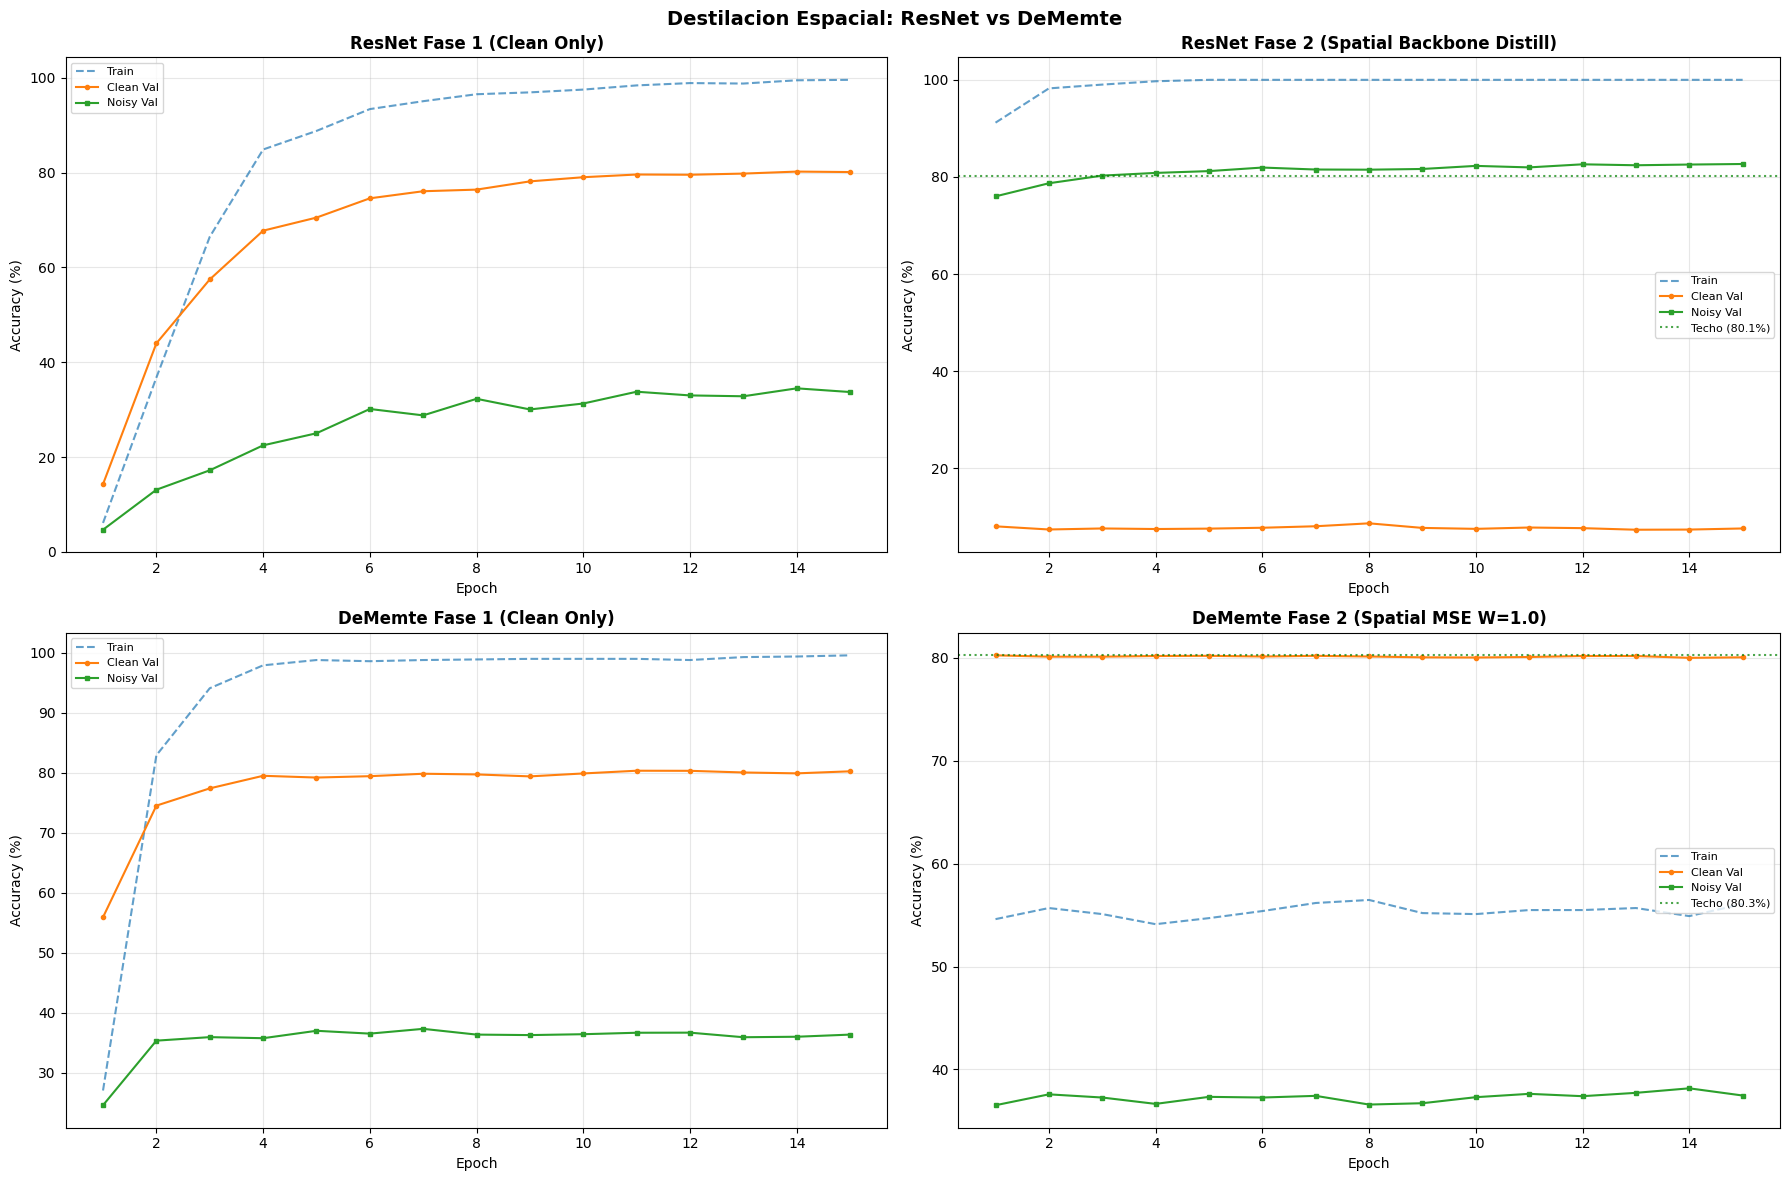

In [12]:
#  Curvas de entrenamiento (2x2) 

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
ep1 = range(1, EPOCHS_P1 + 1)
ep2 = range(1, EPOCHS_P2 + 1)

for ax, hist, title, techo in [
    (axes[0, 0], history_resnet_p1, 'ResNet Fase 1 (Clean Only)', None),
    (axes[0, 1], history_resnet_p2, 'ResNet Fase 2 (Spatial Backbone Distill)', resnet_p1_clean),
    (axes[1, 0], history_dm_p1,     'DeMemte Fase 1 (Clean Only)', None),
    (axes[1, 1], history_dm_p2,     f'DeMemte Fase 2 (Spatial MSE W={SPATIAL_MSE_W})', dm_p1_clean),
]:
    ep = ep1 if 'Fase 1' in title else ep2
    ax.plot(ep, hist['train_acc'], '--', alpha=0.7, label='Train')
    ax.plot(ep, hist['clean_acc'], '-o', markersize=3, label='Clean Val')
    ax.plot(ep, hist['noisy_acc'], '-s', markersize=3, label='Noisy Val')
    if techo is not None:
        ax.axhline(y=techo, color='green', linestyle=':', alpha=0.7, label=f'Techo ({techo:.1f}%)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Destilacion Espacial: ResNet vs DeMemte', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

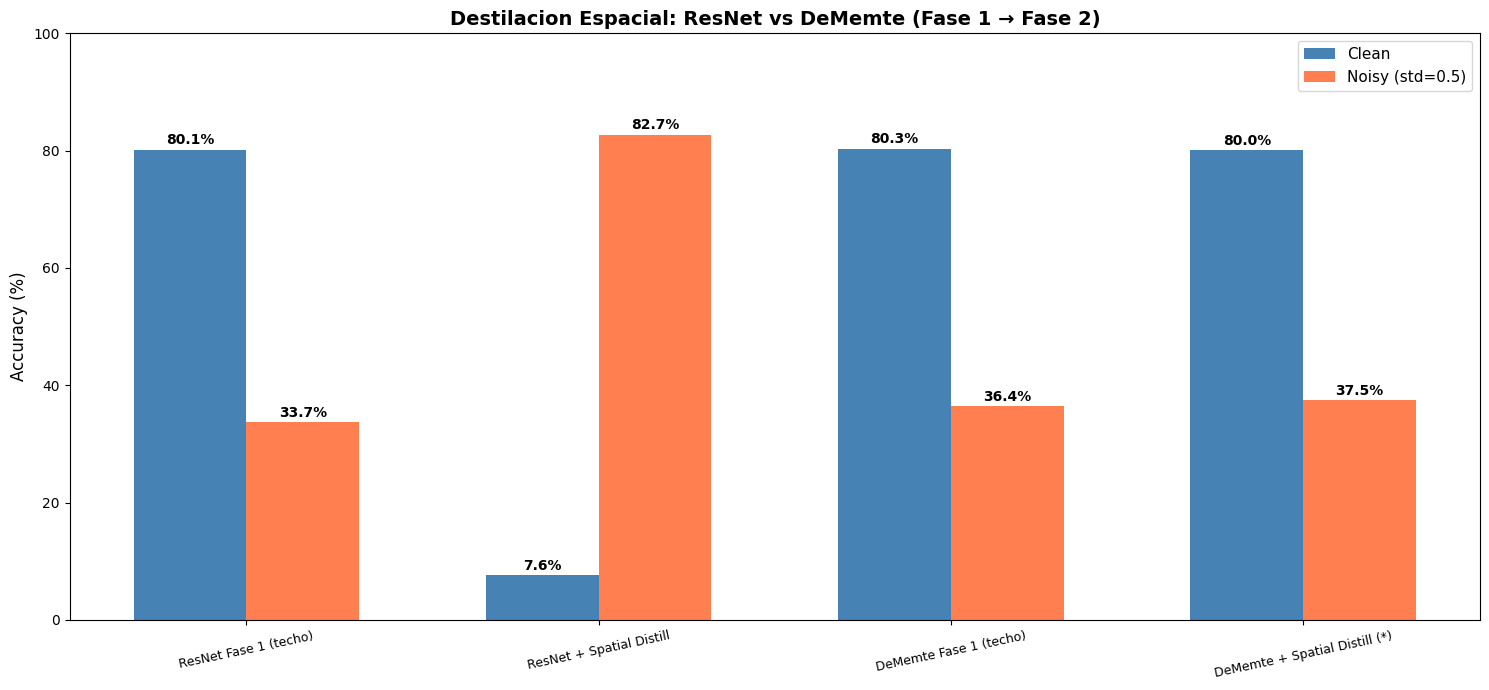

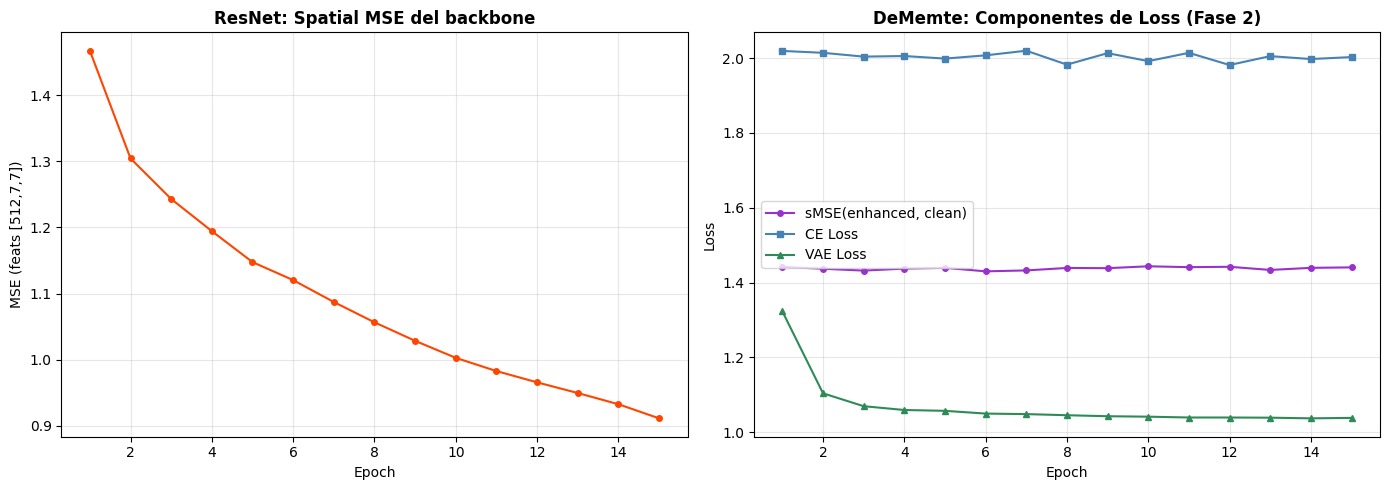

In [13]:
#  Bar chart comparativo ─

names      = list(results.keys())
clean_vals = [results[n]['clean'] for n in names]
noisy_vals = [results[n]['noisy'] for n in names]
x = np.arange(len(names))
w = 0.32

fig, ax = plt.subplots(figsize=(15, 7))
b1 = ax.bar(x - w/2, clean_vals, w, label='Clean', color='steelblue')
b2 = ax.bar(x + w/2, noisy_vals, w, label=f'Noisy (std={NOISE_STD})', color='coral')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Destilacion Espacial: ResNet vs DeMemte (Fase 1 → Fase 2)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9, rotation=12)
ax.legend(fontsize=11); ax.set_ylim(0, 100)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

#  Evolucion Spatial MSE Fase 2 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep2 = range(1, EPOCHS_P2 + 1)

ax = axes[0]
ax.plot(ep2, history_resnet_p2['spatial_mse'], '-o', markersize=4, color='orangered')
ax.set_title('ResNet: Spatial MSE del backbone', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (feats [512,7,7])')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ep2, history_dm_p2['spatial_mse'], '-o', markersize=4, color='darkorchid', label='sMSE(enhanced, clean)')
ax.plot(ep2, history_dm_p2['ce_loss'],     '-s', markersize=4, color='steelblue',  label='CE Loss')
ax.plot(ep2, history_dm_p2['vae_loss'],    '-^', markersize=4, color='seagreen',   label='VAE Loss')
ax.set_title('DeMemte: Componentes de Loss (Fase 2)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
#  Guardar modelos y metadata 
import os, json

OUT_DIR = '../out/dememte_spatial_distillation_flowers102'
os.makedirs(OUT_DIR, exist_ok=True)

torch.save(resnet.state_dict(),  os.path.join(OUT_DIR, 'resnet_spatial_p2.pth'))
torch.save(model.state_dict(),   os.path.join(OUT_DIR, 'dememte_spatial_p2.pth'))

meta = {
    'experiment':         'spatial_memory_distillation',
    'distillation_level': 'spatial_2d_7x7',
    'spatial_map_shape':  '[B, 512, 7, 7]',
    'num_elements':       512 * 7 * 7,
    'SPATIAL_MSE_W':      SPATIAL_MSE_W,
    'VAE_WEIGHT':         VAE_WEIGHT,
    'SPARSITY_WEIGHT':    SPARSITY_WEIGHT,
    'EPOCHS_P1':          EPOCHS_P1,
    'EPOCHS_P2':          EPOCHS_P2,
    'BATCH_SIZE':         BATCH_SIZE,
    'NOISE_STD':          NOISE_STD,
    'results':            results,
    'history_resnet_p1':  history_resnet_p1,
    'history_resnet_p2':  history_resnet_p2,
    'history_dm_p1':      {k: v for k, v in history_dm_p1.items()},
    'history_dm_p2':      {k: v for k, v in history_dm_p2.items()},
}
with open(os.path.join(OUT_DIR, 'metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Guardado en: {OUT_DIR}")
print("\nResumen final:")
for name, r in results.items():
    gap = r['clean'] - r['noisy']
    print(f"  {name:40s}  clean={r['clean']:.2f}%  noisy={r['noisy']:.2f}%  gap={gap:.2f}%")

Guardado en: ../out/dememte_spatial_distillation_flowers102

Resumen final:
  ResNet Fase 1 (techo)                     clean=80.14%  noisy=33.71%  gap=46.43%
  ResNet + Spatial Distill                  clean=7.59%  noisy=82.66%  gap=-75.07%
  DeMemte Fase 1 (techo)                    clean=80.27%  noisy=36.38%  gap=43.89%
  DeMemte + Spatial Distill (*)             clean=80.05%  noisy=37.47%  gap=42.58%
